Dispositivo de cálculo: cpu
Iniciando entrenamiento de Regresión...
Entrenamiento completado. Mejor MSE en prueba: 22265.87


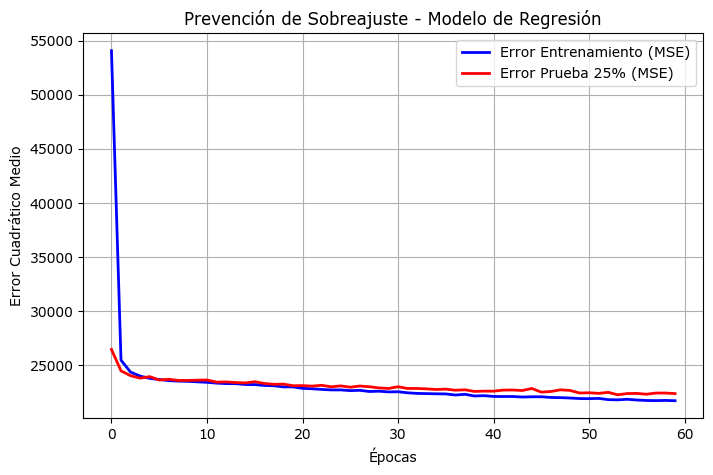

In [7]:
# 1. IMPORTACIÓN DE LIBRERÍAS PERMITIDAS
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Configuración del dispositivo (GPU si está disponible, sino CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo de cálculo: {device}")


# 1. Cargar el dataset de Kaggle
df_bike = pd.read_csv('train.csv')

# 2. Evitar la "Fuga de Datos" (Data Leakage)
# Eliminamos 'datetime' porque no es numérico directo.
# Eliminamos 'casual' y 'registered' porque sumados dan exactamente 'count' (trampa matemática).
df_bike = df_bike.drop(['datetime', 'casual', 'registered'], axis=1)

# 3. Mezclar aleatoriamente (Shuffle manual) para evitar sesgos temporales
df_bike = df_bike.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Separar matriz de características (X) y vector objetivo (y)
X_bike = df_bike.drop('count', axis=1).values.astype(float)
y_bike = df_bike['count'].values.astype(float)

# 5. Normalización Estadística Manual (Z-score)
# Extraído de tu código base: (X - mu) / sigma
mu = np.mean(X_bike, axis=0)
sigma = np.std(X_bike, axis=0)
sigma[sigma == 0] = 1e-8 # Evitar división por cero
X_bike_norm = (X_bike - mu) / sigma

# 6. División estricta 75% Entrenamiento / 25% Prueba (Requisito del examen)
limite = int(0.75 * len(X_bike_norm))
X_train_b, X_test_b = X_bike_norm[:limite], X_bike_norm[limite:]
y_train_b, y_test_b = y_bike[:limite], y_bike[limite:]


class RegresionDataset(Dataset):
    """Encapsula los datos en tensores para PyTorch"""
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        # unsqueeze(1) transforma [N] a [N, 1] requerido para regresión
        self.Y = torch.from_numpy(Y).float().unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# Instanciamos los DataLoaders (Generan mini-batches automáticos)
loaders_bike = {
    'train': DataLoader(RegresionDataset(X_train_b, y_train_b), batch_size=128, shuffle=True),
    'test': DataLoader(RegresionDataset(X_test_b, y_test_b), batch_size=128, shuffle=False)
}


class RegresionMLP(torch.nn.Module):
    def __init__(self, D_in):
        super(RegresionMLP, self).__init__()
        # Arquitectura en embudo para extraer características complejas
        self.fc1 = torch.nn.Linear(D_in, 64)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(64, 32)
        # Salida de 1 sola neurona lineal (predice un valor continuo)
        self.fc3 = torch.nn.Linear(32, 1) 

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

modelo_reg = RegresionMLP(X_train_b.shape[1]).to(device)

# =====================================================================
# FASE D: ENTRENAMIENTO ANTI-OVERFITTING (Patrón Checkpoint)
# =====================================================================

optimizer = torch.optim.Adam(modelo_reg.parameters(), lr=0.005)
criterion = torch.nn.MSELoss() # Error Cuadrático Medio para Regresión

mejor_loss_prueba = float('inf') # Infinito inicial
train_losses, test_losses = [], []
epochs = 60

print("Iniciando entrenamiento de Regresión...")
for epoch in range(1, epochs + 1):
    
    # --- Entrenamiento ---
    modelo_reg.train()
    loss_epoca = []
    for X_b, y_b in loaders_bike['train']:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        y_hat = modelo_reg(X_b)
        loss = criterion(y_hat, y_b)
        loss.backward()
        optimizer.step()
        loss_epoca.append(loss.item())
    
    train_losses.append(np.mean(loss_epoca))
    
    # --- Validación (25% Prueba) ---
    modelo_reg.eval()
    val_loss = []
    with torch.no_grad(): # Desactivar cálculo de gradientes
        for X_b, y_b in loaders_bike['test']:
            X_b, y_b = X_b.to(device), y_b.to(device)
            y_hat = modelo_reg(X_b)
            val_loss.append(criterion(y_hat, y_b).item())
            
    val_loss_mean = np.mean(val_loss)
    test_losses.append(val_loss_mean)
    
    # --- CHECKPOINT: Guardar solo si el error en prueba disminuye ---
    if val_loss_mean < mejor_loss_prueba:
        mejor_loss_prueba = val_loss_mean
        torch.save(modelo_reg.state_dict(), 'mejor_regresion.pt')

print(f"Entrenamiento completado. Mejor MSE en prueba: {mejor_loss_prueba:.2f}")

# Cargar el mejor modelo para la evaluación final
modelo_reg.load_state_dict(torch.load('mejor_regresion.pt'))

# =====================================================================
# FASE E: VISUALIZACIÓN DE RESULTADOS
# =====================================================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Error Entrenamiento (MSE)', color='blue', lw=2)
plt.plot(test_losses, label='Error Prueba 25% (MSE)', color='red', lw=2)
plt.title('Prevención de Sobreajuste - Modelo de Regresión')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 1. Carga e Imputación de Valores Faltantes
df_meningitis = pd.read_csv('meningitis_dataset.csv')

# Imputación: Llenar nulos numéricos con la mediana y categóricos con la moda
num_cols = df_meningitis.select_dtypes(include=[np.number]).columns
cat_cols = df_meningitis.select_dtypes(exclude=[np.number]).columns

df_meningitis[num_cols] = df_meningitis[num_cols].fillna(df_meningitis[num_cols].median())
for col in cat_cols:
    df_meningitis[col] = df_meningitis[col].fillna(df_meningitis[col].mode()[0])

# Transformar categóricos a números (Codificación básica)
df_meningitis = pd.get_dummies(df_meningitis, drop_first=True)

# 2. Separar Datos y División 75/25
# Asumiendo que la columna objetivo se llama 'diagnostico_final' (Reemplazar con el nombre real)
target_col = 'diagnostico_final' 

X_men = df_meningitis.drop(target_col, axis=1).values.astype(float)
y_men_original = df_meningitis[target_col].values

# Mapear etiquetas de texto a enteros (0, 1, 2...)
clases_unicas = np.unique(y_men_original)
mapeo = {val: idx for idx, val in enumerate(clases_unicas)}
y_men = np.vectorize(mapeo.get)(y_men_original)

# Mezclar y Dividir
indices = np.random.permutation(len(X_men))
limite_m = int(0.75 * len(X_men))

X_train_m, X_test_m = X_men[indices[:limite_m]], X_men[indices[limite_m:]]
y_train_m, y_test_m = y_men[indices[:limite_m]], y_men[indices[limite_m:]]

# 3. DataLoaders
class ClasificacionDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long() # .long() requerido por CrossEntropy

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

loaders_men = {
    'train': DataLoader(ClasificacionDataset(X_train_m, y_train_m), batch_size=32, shuffle=True),
    'test': DataLoader(ClasificacionDataset(X_test_m, y_test_m), batch_size=32, shuffle=False)
}

# 4. Arquitectura de Red Neuronal Profunda con Prevención de Sobreajuste (Dropout)
class ClasificadorMLP(torch.nn.Module):
    def __init__(self, D_in, num_clases):
        super(ClasificadorMLP, self).__init__()
        self.fc1 = torch.nn.Linear(D_in, 128)
        self.dropout = torch.nn.Dropout(0.3) # Previene sobreajuste apagando neuronas
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, num_clases)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

modelo_clasificacion = ClasificadorMLP(X_train_m.shape[1], len(clases_unicas)).to(device)

# 5. Entrenamiento y Checkpoints
optimizer = torch.optim.Adam(modelo_clasificacion.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

mejor_acc = 0.0
train_accs, test_accs = [], []

for epoch in range(1, 41):
    modelo_clasificacion.train()
    acc_epoca = []
    for X_b, y_b in loaders_men['train']:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        y_hat = modelo_clasificacion(X_b)
        loss = criterion(y_hat, y_b)
        loss.backward()
        optimizer.step()
        
        acc = (y_b == torch.argmax(y_hat, axis=1)).float().mean().item()
        acc_epoca.append(acc)
    train_accs.append(np.mean(acc_epoca))
    
    # Evaluación en conjunto de prueba
    modelo_clasificacion.eval()
    acc_prueba = []
    with torch.no_grad():
        for X_b, y_b in loaders_men['test']:
            X_b, y_b = X_b.to(device), y_b.to(device)
            y_hat = modelo_clasificacion(X_b)
            acc = (y_b == torch.argmax(y_hat, axis=1)).float().mean().item()
            acc_prueba.append(acc)
            
    acc_actual = np.mean(acc_prueba)
    test_accs.append(acc_actual)
    
    # Guardar modelo si la precisión en el conjunto de prueba es la mejor
    if acc_actual > mejor_acc:
        mejor_acc = acc_actual
        torch.save(modelo_clasificacion.state_dict(), 'mejor_clasificador.pt')

print(f"Mejor Precisión (Accuracy) en prueba alcanzada: {mejor_acc * 100:.2f}%")

# 6. Gráficos de Precisión
plt.plot(train_accs, label='Precisión Entrenamiento')
plt.plot(test_accs, label='Precisión Prueba (25%)')
plt.title('Precisión vs Épocas - Clasificador de Meningitis')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

Precio predicho (Descenso por el Gradiente): $735,292.57
